In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.linear_model import LinearRegression

##  LOAD DAN CLEANING DATA

In [2]:
df = pd.read_csv('paddydataset.csv')

print(f"Jumlah missing values sebelum cleaning: {df.isnull().sum().sum()}")
df = df.dropna()                 
df = df.drop_duplicates()     

print(f"Dimensi dataset setelah cleaning: {df.shape}")
print(f"Jumlah missing values setelah cleaning: {df.isnull().sum().sum()}")

Jumlah missing values sebelum cleaning: 0
Dimensi dataset setelah cleaning: (2338, 45)
Jumlah missing values setelah cleaning: 0


## Feature Importance

In [3]:
X_all = df.drop(columns=['Paddy yield(in Kg)'])
y = df['Paddy yield(in Kg)']

X_all_encoded = pd.get_dummies(X_all, drop_first=True)

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all_encoded, y, test_size=0.2, random_state=42
)

scaler_baseline = StandardScaler()
X_train_scaled_all = scaler_baseline.fit_transform(X_train_all)

rf_baseline = RandomForestRegressor(n_estimators=100, random_state=42)
rf_baseline.fit(X_train_scaled_all, y_train_all)

df_importance = pd.DataFrame({
    'Feature': X_all_encoded.columns,
    'Importance': rf_baseline.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(df_importance.head(45))

                               Feature  Importance
0                            Hectares     0.128026
9                Micronutrients_70Days    0.103726
8                       Potassh_50Days    0.101339
7                          Urea_40Days    0.101234
10                   Pest_60Day(in ml)    0.098776
2              LP_Mainfield(in Tonnes)    0.087136
5                           DAP_20days    0.085898
35                   Trash(in bundles)    0.068486
1                      Seedrate(in Kg)    0.067157
4            LP_nurseryarea(in Tonnes)    0.063936
6                  Weed28D_thiobencarb    0.055590
3                 Nursery area (Cents)    0.036133
44                         Nursery_wet    0.000467
43                     Soil Types_clay    0.000455
41                 Variety_delux ponni    0.000223
42                     Variety_ponmani    0.000212
24                    Max temp_D61_D90    0.000105
27    Inst Wind Speed_D1_D30(in Knots)    0.000105
31            Relative Humidity

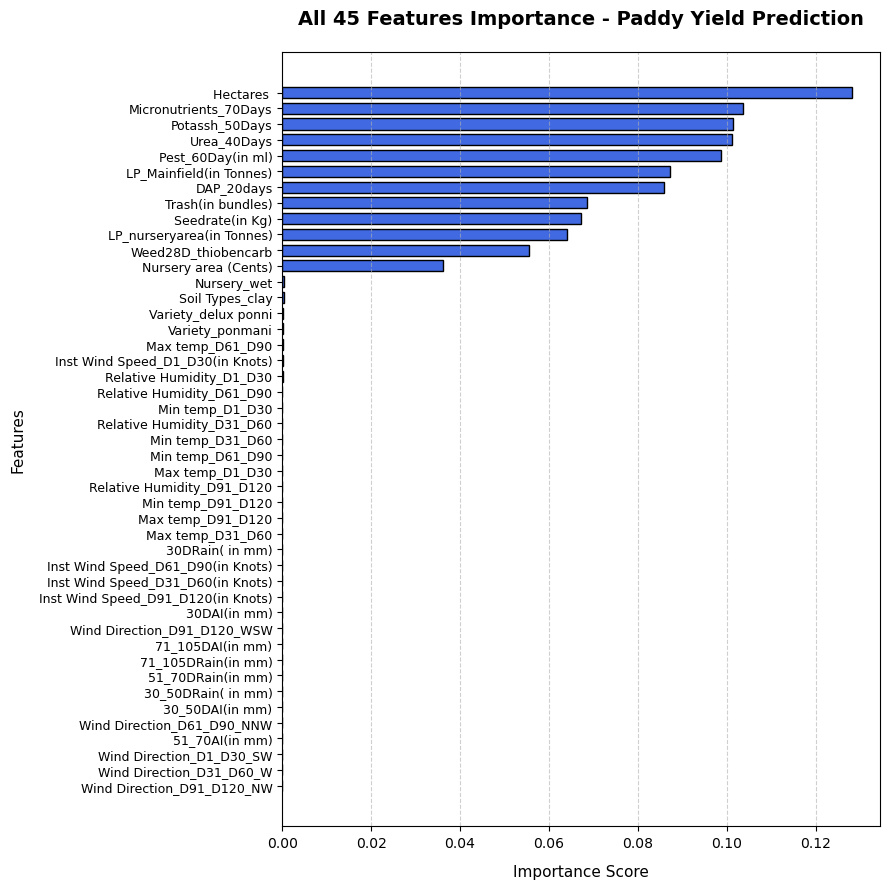

In [4]:
df_bar = df_importance.head(45).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(9, 9))
plt.barh(df_bar['Feature'], df_bar['Importance'], color='royalblue', edgecolor='black', height=0.7)
plt.title('All 45 Features Importance - Paddy Yield Prediction', fontsize=14, fontweight='bold', pad=20)

plt.xlabel('Importance Score', fontsize=11, labelpad=10)
plt.ylabel('Features', fontsize=11, labelpad=10)

plt.yticks(fontsize=9)
plt.xticks(fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig('feature_importance_all_45.png', dpi=300, bbox_inches='tight')

plt.show()

## FEATURE IMPORTANCE (SELECTED)

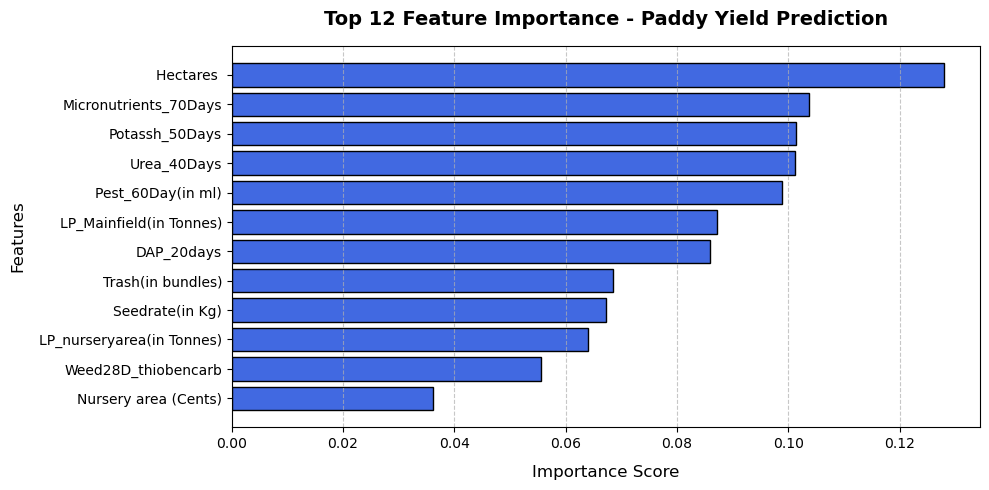

In [5]:
df_top12_bar = df_importance.head(12).sort_values(by='Importance', ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(df_top12_bar['Feature'], df_top12_bar['Importance'], color='royalblue', edgecolor='black')

plt.title('Top 12 Feature Importance - Paddy Yield Prediction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Importance Score', fontsize=12, labelpad=10)
plt.ylabel('Features', fontsize=12, labelpad=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('feature_importance_top12.png', dpi=300)
plt.show()

## SELEKSI 12 FITUR TERBAIK

In [6]:
# 12 FITUR TERBAIK (FEATURE SELECTION)
# 1. Hectares: Luas total lahan pertanian utama yang digarap.
# 2. Micronutrients_70Days: Pemberian unsur hara mikro pada fase pembuahan hari ke-70.
# 3. Potassh_50Days: Aplikasi pupuk Kalium (Potash) pada fase generatif hari ke-50.
# 4. Urea_40Days: Aplikasi pupuk Nitrogen (Urea) pada fase vegetatif hari ke-40.
# 5. Pest_60Day(in ml): Dosis pestisida untuk perlindungan komprehensif hama di hari ke-60.
# 6. LP_Mainfield(in Tonnes): Skala persiapan lahan utama sebelum masa tanam dimulai.
# 7. DAP_20days: Aplikasi pupuk dasar Di-ammonium Phosphate di hari ke-20.
# 8. Trash(in bundles): Manajemen kebersihan limbah pertanian atau jerami penutup lahan.
# 9. Seedrate(in Kg): Kuantitas bobot benih padi yang disemai pada petak pembibitan.
# 10. LP_nurseryarea(in Tonnes): Skala persiapan tanah khusus pada area pembibitan awal.
# 11. Weed28D_thiobencarb: Pengendalian gulma kimiawi menggunakan Thiobencarb di hari ke-28.
# 12. Nursery area (Cents): Luas total area pembibitan khusus dalam satuan ukuran Cents.

selected_features = [
    'Hectares ', 
    'Micronutrients_70Days', 
    'Potassh_50Days', 
    'Urea_40Days', 
    'Pest_60Day(in ml)', 
    'LP_Mainfield(in Tonnes)', 
    'DAP_20days', 
    'Trash(in bundles)', 
    'Seedrate(in Kg)', 
    'LP_nurseryarea(in Tonnes)',
    'Weed28D_thiobencarb',
    'Nursery area (Cents)'
]
target = 'Paddy yield(in Kg)'

X_final = df[selected_features]
y_final = df[target]

X_encoded_final = pd.get_dummies(X_final, drop_first=True)
print("Jumlah fitur setelah encoding:", X_encoded_final.shape[1])






Jumlah fitur setelah encoding: 12


## SPLIT DATA

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded_final, y_final, test_size=0.2, random_state=42
)

## STANDARD SCALING

In [8]:
scaler_final = StandardScaler()
X_train_scaled = scaler_final.fit_transform(X_train)
X_test_scaled = scaler_final.transform(X_test)

X_train_final_df = pd.DataFrame(X_train_scaled, columns=X_encoded_final.columns)
X_test_final_df = pd.DataFrame(X_test_scaled, columns=X_encoded_final.columns)

In [9]:
pd.set_option('display.max_columns', None)
print("=== 5 BARIS PERTAMA DATASET (12 FITUR SEBELUM SCALING) ===")
display(X_final.head())


=== 5 BARIS PERTAMA DATASET (12 FITUR SEBELUM SCALING) ===


,Hectares,Micronutrients_70Days,Potassh_50Days,Urea_40Days,Pest_60Day(in ml),LP_Mainfield(in Tonnes),DAP_20days,Trash(in bundles),Seedrate(in Kg),LP_nurseryarea(in Tonnes),Weed28D_thiobencarb,Nursery area (Cents)
0,6,90,62.28,162.78,3600,75.0,240,540,150,6,12,120
1,6,90,62.28,162.78,3600,75.0,240,600,150,6,12,120
2,6,90,62.28,162.78,3600,75.0,240,600,150,6,12,120
3,6,90,62.28,162.78,3600,75.0,240,540,150,6,12,120
4,6,90,62.28,162.78,3600,75.0,240,600,150,6,12,120


In [10]:
print("=== 5 BARIS PERTAMA DATASET (12 FITUR SETELAH SCALING) ===")
display(X_train_final_df.head())

=== 5 BARIS PERTAMA DATASET (12 FITUR SETELAH SCALING) ===


,Hectares,Micronutrients_70Days,Potassh_50Days,Urea_40Days,Pest_60Day(in ml),LP_Mainfield(in Tonnes),DAP_20days,Trash(in bundles),Seedrate(in Kg),LP_nurseryarea(in Tonnes),Weed28D_thiobencarb,Nursery area (Cents)
0,0.190418,0.190418,0.190418,0.190418,0.190418,0.190418,0.190418,0.470695,0.190418,0.190418,0.190418,0.190418
1,0.879164,0.879164,0.879164,0.879164,0.879164,0.879164,0.879164,0.839011,0.879164,0.879164,0.879164,0.879164
2,1.567909,1.567909,1.567909,1.567909,1.567909,1.567909,1.567909,1.060000,1.567909,1.567909,1.567909,1.567909
3,0.190418,0.190418,0.190418,0.190418,0.190418,0.190418,0.190418,-0.118609,0.190418,0.190418,0.190418,0.190418
4,0.879164,0.879164,0.879164,0.879164,0.879164,0.879164,0.879164,0.470695,0.879164,0.879164,0.879164,0.879164


## CROSS-VALIDATION & HYPERPARAMETER TUNING

In [11]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

param_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [None, 10, 20]
}

param_knn = {
    'n_neighbors': [3, 5, 7],
    'weights': ['uniform', 'distance']
}

print("=== TUNING & 5-FOLD CROSS-VALIDATION ===")

grid_rf = GridSearchCV(RandomForestRegressor(random_state=42), param_rf, cv=kf, scoring='r2', n_jobs=-1)
grid_rf.fit(X_train_final_df, y_train)

print("=== TUNING KNN ===")
grid_knn = GridSearchCV(KNeighborsRegressor(), param_knn, cv=kf, scoring='r2', n_jobs=-1)
grid_knn.fit(X_train_final_df, y_train)

lr_model = LinearRegression()
lr_model.fit(X_train_final_df, y_train)

print(f"Best params RF: {grid_rf.best_params_}")
print(f"Best params KNN: {grid_knn.best_params_}")





=== TUNING & 5-FOLD CROSS-VALIDATION ===
=== TUNING KNN ===
Best params RF: {'max_depth': None, 'n_estimators': 150}
Best params KNN: {'n_neighbors': 7, 'weights': 'uniform'}


## EVALUASI MODEL PADA DATA TEST

In [12]:


models_final = {
    "Optimized Random Forest": grid_rf.best_estimator_,
    "Optimized KNN Regressor": grid_knn.best_estimator_,
    "Linear Regression (Baseline)": lr_model
}

performance_results = []

for name, model in models_final.items():
    y_pred = model.predict(X_test_scaled)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    abs_errors = np.abs(y_test - y_pred)
    p90 = np.percentile(abs_errors, 90)
    
    if name == "Optimized Random Forest":
        best_params = str(grid_rf.best_params_)
    elif name == "Optimized KNN Regressor":
        best_params = str(grid_knn.best_params_)
    else:
        best_params = "N/A"
    
    performance_results.append({
        'Model Name': name,
        'Best Params': best_params,
        'MAE (Kg)': round(mae, 2),
        'P90 Error (Kg)': round(p90, 2),
        'RMSE (Kg)': round(rmse, 2),
        'R2 Score': round(r2, 4)
    })

df_report = pd.DataFrame(performance_results)
print("=== PERBANDINGAN MODEL (dengan P90) ===")
print(df_report.to_string(index=False))

=== PERBANDINGAN MODEL (dengan P90) ===
                  Model Name                              Best Params  MAE (Kg)  P90 Error (Kg)  RMSE (Kg)  R2 Score
     Optimized Random Forest {'max_depth': None, 'n_estimators': 150}    657.62         1426.74     912.78    0.9903
     Optimized KNN Regressor {'n_neighbors': 7, 'weights': 'uniform'}    682.38         1458.57     937.67    0.9897
Linear Regression (Baseline)                                      N/A    762.88         1584.16    1021.45    0.9878


d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [13]:

rf_row = df_report[df_report['Model Name'] == "Optimized Random Forest"].iloc[0]
knn_row = df_report[df_report['Model Name'] == "Optimized KNN Regressor"].iloc[0]
lr_row = df_report[df_report['Model Name'] == "Linear Regression (Baseline)"].iloc[0]

print("="*60)
print("PERBANDINGAN SELISIH ANTAR MODEL")
print("="*60)

print("\n--- Random Forest vs KNN ---")
print(f"MAE  : {rf_row['MAE (Kg)'] - knn_row['MAE (Kg)']:+.2f} Kg  (RF {'lebih baik' if rf_row['MAE (Kg)'] < knn_row['MAE (Kg)'] else 'lebih buruk'})")
print(f"P90  : {rf_row['P90 Error (Kg)'] - knn_row['P90 Error (Kg)']:+.2f} Kg  (RF {'lebih baik' if rf_row['P90 Error (Kg)'] < knn_row['P90 Error (Kg)'] else 'lebih buruk'})")
print(f"RMSE : {rf_row['RMSE (Kg)'] - knn_row['RMSE (Kg)']:+.2f} Kg  (RF {'lebih baik' if rf_row['RMSE (Kg)'] < knn_row['RMSE (Kg)'] else 'lebih buruk'})")
print(f"R²   : {rf_row['R2 Score'] - knn_row['R2 Score']:+.4f}    (RF {'lebih baik' if rf_row['R2 Score'] > knn_row['R2 Score'] else 'lebih buruk'})")

print("\n--- Random Forest vs Linear Regression ---")
print(f"MAE  : {rf_row['MAE (Kg)'] - lr_row['MAE (Kg)']:+.2f} Kg  (RF {'lebih baik' if rf_row['MAE (Kg)'] < lr_row['MAE (Kg)'] else 'lebih buruk'})")
print(f"P90  : {rf_row['P90 Error (Kg)'] - lr_row['P90 Error (Kg)']:+.2f} Kg  (RF {'lebih baik' if rf_row['P90 Error (Kg)'] < lr_row['P90 Error (Kg)'] else 'lebih buruk'})")
print(f"RMSE : {rf_row['RMSE (Kg)'] - lr_row['RMSE (Kg)']:+.2f} Kg  (RF {'lebih baik' if rf_row['RMSE (Kg)'] < lr_row['RMSE (Kg)'] else 'lebih buruk'})")
print(f"R²   : {rf_row['R2 Score'] - lr_row['R2 Score']:+.4f}    (RF {'lebih baik' if rf_row['R2 Score'] > lr_row['R2 Score'] else 'lebih buruk'})")

print("\n--- KNN vs Linear Regression ---")
print(f"MAE  : {knn_row['MAE (Kg)'] - lr_row['MAE (Kg)']:+.2f} Kg  (KNN {'lebih baik' if knn_row['MAE (Kg)'] < lr_row['MAE (Kg)'] else 'lebih buruk'})")
print(f"P90  : {knn_row['P90 Error (Kg)'] - lr_row['P90 Error (Kg)']:+.2f} Kg  (KNN {'lebih baik' if knn_row['P90 Error (Kg)'] < lr_row['P90 Error (Kg)'] else 'lebih buruk'})")
print(f"RMSE : {knn_row['RMSE (Kg)'] - lr_row['RMSE (Kg)']:+.2f} Kg  (KNN {'lebih baik' if knn_row['RMSE (Kg)'] < lr_row['RMSE (Kg)'] else 'lebih buruk'})")
print(f"R²   : {knn_row['R2 Score'] - lr_row['R2 Score']:+.4f}    (KNN {'lebih baik' if knn_row['R2 Score'] > lr_row['R2 Score'] else 'lebih buruk'})")

PERBANDINGAN SELISIH ANTAR MODEL

--- Random Forest vs KNN ---
MAE  : -24.76 Kg  (RF lebih baik)
P90  : -31.83 Kg  (RF lebih baik)
RMSE : -24.89 Kg  (RF lebih baik)
R²   : +0.0006    (RF lebih baik)

--- Random Forest vs Linear Regression ---
MAE  : -105.26 Kg  (RF lebih baik)
P90  : -157.42 Kg  (RF lebih baik)
RMSE : -108.67 Kg  (RF lebih baik)
R²   : +0.0025    (RF lebih baik)

--- KNN vs Linear Regression ---
MAE  : -80.50 Kg  (KNN lebih baik)
P90  : -125.59 Kg  (KNN lebih baik)
RMSE : -83.78 Kg  (KNN lebih baik)
R²   : +0.0019    (KNN lebih baik)


In [14]:
print(df['Paddy yield(in Kg)'].describe())
print("\nPersentil 90:", df['Paddy yield(in Kg)'].quantile(0.9))

count     2338.000000
mean     22610.117622
std       9265.184949
min       5410.000000
25%      16359.000000
50%      24644.000000
75%      31035.000000
max      38814.000000
Name: Paddy yield(in Kg), dtype: float64

Persentil 90: 32090.0


In [15]:
print(f"Range yield: {y.min()} - {y.max()} Kg")

Range yield: 5410 - 38814 Kg


## CEK OVERFITTING 

In [16]:
print("\n=== CEK OVERFITTING ===")
for name, model in models_final.items():
    train_pred = model.predict(X_train_scaled)
    test_pred = model.predict(X_test_scaled)
    train_r2 = r2_score(y_train, train_pred)
    test_r2 = r2_score(y_test, test_pred)
    print(f"\n{name}")
    print(f"  Train R² : {train_r2:.4f}")
    print(f"  Test R²  : {test_r2:.4f}")
    print(f"  Gap (Train - Test) : {train_r2 - test_r2:.4f}")


=== CEK OVERFITTING ===

Optimized Random Forest
  Train R² : 0.9922
  Test R²  : 0.9903
  Gap (Train - Test) : 0.0019

Optimized KNN Regressor
  Train R² : 0.9916
  Test R²  : 0.9897
  Gap (Train - Test) : 0.0019

Linear Regression (Baseline)
  Train R² : 0.9893
  Test R²  : 0.9878
  Gap (Train - Test) : 0.0015


d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but KNeighborsRegressor was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(
d:\readFilee\New folder\Lib\site-packages\sklearn\base.py:493: UserWarning: X d

## UJI LATENSI PREDIKSI

In [17]:
import time

sample_data = X_test_final_df.iloc[[0]]

start_time_rf = time.time()
pred_rf = models_final["Optimized Random Forest"].predict(sample_data)
latency_rf = (time.time() - start_time_rf) * 1000 

start_time_knn = time.time()
pred_knn = models_final["Optimized KNN Regressor"].predict(sample_data)
latency_knn = (time.time() - start_time_knn) * 1000

start_time_lr = time.time()
pred_lr = models_final["Linear Regression (Baseline)"].predict(sample_data)
latency_lr = (time.time() - start_time_lr) * 1000

print("=== HASIL UJI LATENSI PREDIKSI (PER SATU BARIS DATA) ===")
print(f"Optimized Random Forest : {latency_rf:.2f} ms")
print(f"Optimized KNN Regressor : {latency_knn:.2f} ms")
print(f"Linear Regression       : {latency_lr:.2f} ms")

=== HASIL UJI LATENSI PREDIKSI (PER SATU BARIS DATA) ===
Optimized Random Forest : 15.27 ms
Optimized KNN Regressor : 0.00 ms
Linear Regression       : 6.40 ms


## VISUALISASI AKTUAL VS PREDIKSI 

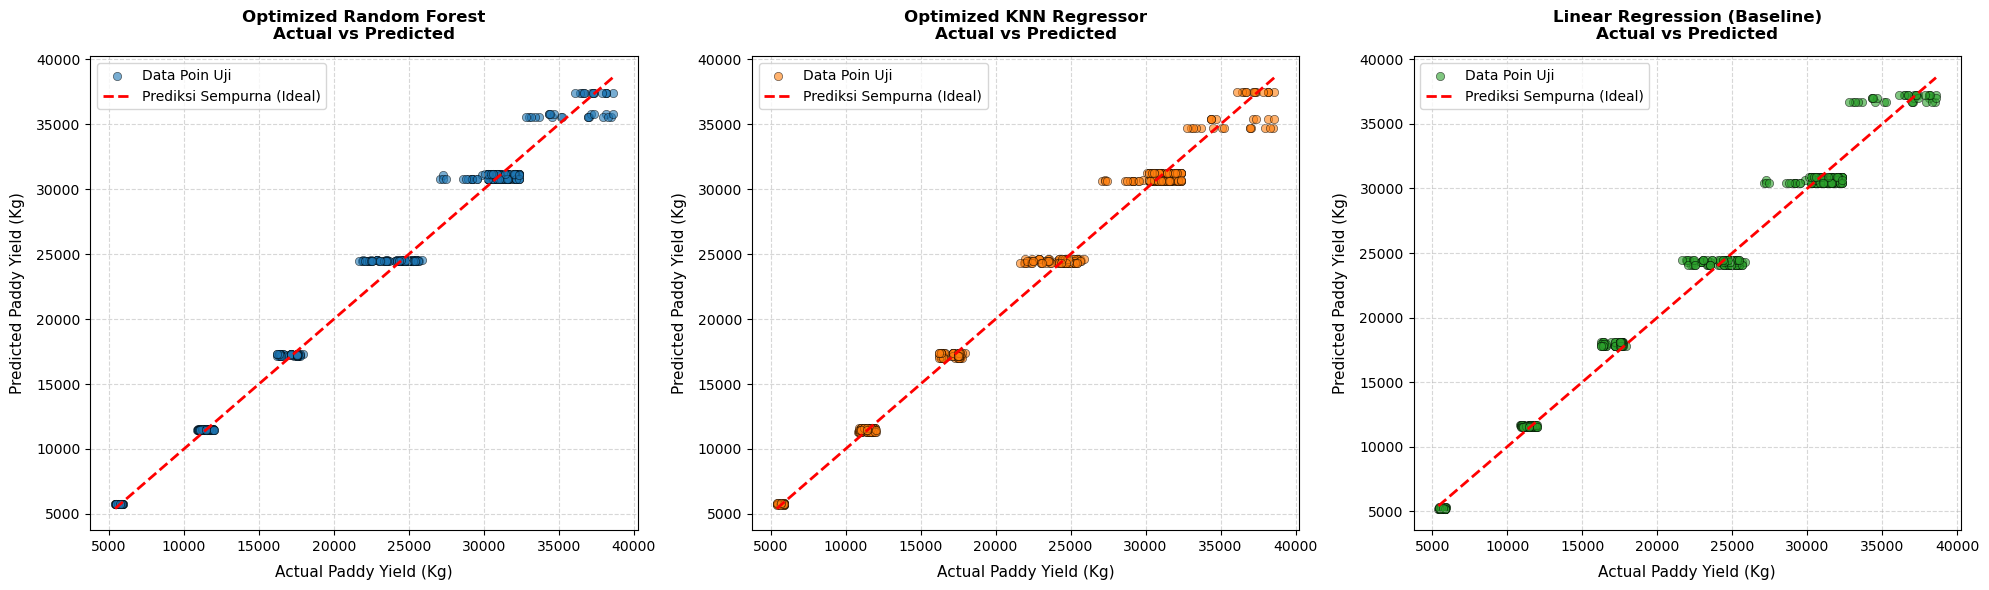

In [18]:
model_colors = {
    "Optimized Random Forest": "#1f77b4",       
    "Optimized KNN Regressor": "#ff7f0e",       
    "Linear Regression (Baseline)": "#2ca02c"   
}

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

for idx, (name, model) in enumerate(models_final.items()):
    y_pred = model.predict(X_test_final_df)
    
    ax = axes[idx]
    
    ax.scatter(
        y_test, 
        y_pred, 
        alpha=0.6, 
        color=model_colors[name], 
        edgecolors='black', 
        linewidths=0.5,
        label='Data Poin Uji'
    )
    
    ax.plot(
        [y_test.min(), y_test.max()], 
        [y_test.min(), y_test.max()], 
        color='red', 
        linestyle='--', 
        linewidth=2,
        label='Prediksi Sempurna (Ideal)'
    )
    
    ax.set_title(f'{name}\nActual vs Predicted', fontsize=12, fontweight='bold', pad=12)
    ax.set_xlabel('Actual Paddy Yield (Kg)', fontsize=11, labelpad=8)
    ax.set_ylabel('Predicted Paddy Yield (Kg)', fontsize=11, labelpad=8)
    ax.grid(True, linestyle='--', alpha=0.5)
    ax.legend(loc='upper left', fontsize=10)

plt.tight_layout()
plt.savefig('actual_vs_predicted_3_models_grid.png', dpi=300, bbox_inches='tight')
plt.show()

## MODEL TERBAIK (RANDOM FOREST)

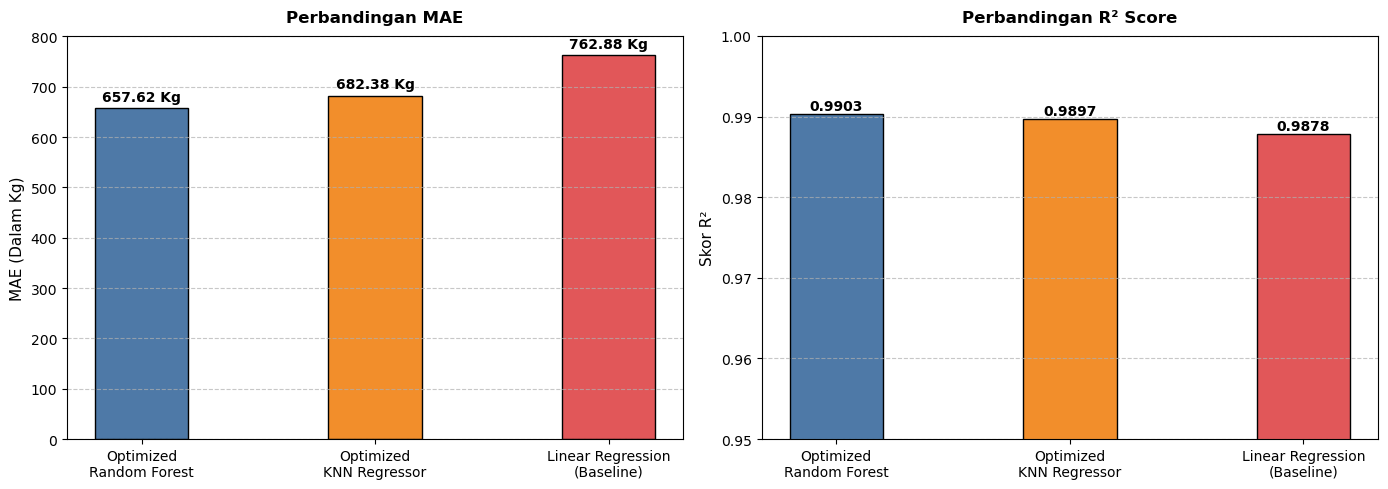

In [19]:
model_label_mapping = {
    "Optimized Random Forest": "Optimized\nRandom Forest",
    "Optimized KNN Regressor": "Optimized\nKNN Regressor",
    "Linear Regression (Baseline)": "Linear Regression\n(Baseline)"
}

model_names_bar = [model_label_mapping[name] for name in df_report['Model Name']]
maes_val = df_report['MAE (Kg)'].tolist()
r2_val = df_report['R2 Score'].tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.bar(model_names_bar, maes_val, color=['#4e79a7', '#f28e2b', '#e15759'], edgecolor='black', width=0.4)
ax1.set_title('Perbandingan MAE', fontsize=12, fontweight='bold', pad=10)
ax1.set_ylabel('MAE (Dalam Kg)', fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(maes_val):
    ax1.text(i, v + 15, f"{v:.2f} Kg", ha='center', fontweight='bold', fontsize=10)

ax2.bar(model_names_bar, r2_val, color=['#4e79a7', '#f28e2b', '#e15759'], edgecolor='black', width=0.4)
ax2.set_title('Perbandingan R² Score', fontsize=12, fontweight='bold', pad=10)
ax2.set_ylabel('Skor R²', fontsize=11)
ax2.set_ylim(0.95, 1.0)
ax2.grid(axis='y', linestyle='--', alpha=0.7)
for i, v in enumerate(r2_val):
    ax2.text(i, v + 0.0005, f"{v:.4f}", ha='center', fontweight='bold', fontsize=10)

plt.tight_layout()
plt.savefig('performance_metrics_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

## SIMPAN MODEL DAN SCALER

In [ ]:
best_model_object = models_final["Optimized Random Forest"]
joblib.dump(best_model_object, 'best_random_forest_model.pkl')

joblib.dump(scaler_final, 'robust_standard_scaler.pkl')
joblib.dump(X_encoded_final.columns.tolist(), 'feature_columns.pkl')

print("Model, Scaler, dan Feature Columns berhasil disimpan.")

Model, Scaler, dan Feature Columns berhasil disimpan.
